In [4]:
# ── Configuracion Google Colab ────────────────────────────────────────────
# En local esta celda no hace nada.
# En Colab clona el repositorio automaticamente.
try:
    import google.colab, os, subprocess
    IN_COLAB = True
    REPO = '/content/analisis-crediticos'
    if not os.path.exists(REPO):
        subprocess.run(['git', 'clone',
                        'https://github.com/uzzielvz/analisis-crediticos.git', REPO],
                       check=True)
    print('Repositorio listo.')
except ImportError:
    IN_COLAB = False
    print('Modo local.')

Repositorio listo.


# Análisis de Mora — vs Plazo, Tasa, Monto
**Fecha de corte:** 06 de marzo de 2026 &nbsp;

---

### Preguntas que responde este análisis

1. ¿El **monto** del crédito se relaciona con los días de mora?
2. ¿El **plazo** (en meses) se relaciona con los días de mora?
2. ¿La **tasa de interes** se relaciona con los días de mora?
3. ¿La **combinación** de monto, tasa y plazo permite predecir si un crédito entrará en mora?

---

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import spearmanr
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score, roc_curve
import subprocess, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
AZUL='#2471A3'; ROJO='#C0392B'; VERDE='#1E8449'; NARANJA='#D35400'; GRIS='#717D7E'

ROOT     = Path('/content/analisis-crediticos') if IN_COLAB else Path('..').resolve()
CSV      = ROOT / 'outputs' / 'dataset_mora.csv'
DATA_DIR = ROOT / 'data'

if not CSV.exists():
    import subprocess as _sp
    _r = _sp.run(['python', str(ROOT/'scripts'/'01_clean_dataset.py')],
                 capture_output=True, text=True)
    if _r.returncode != 0: raise RuntimeError(_r.stderr)
    print(_r.stdout)

df = pd.read_csv(CSV)
df['en_mora'] = (df['dias_mora'] > 0).astype(int)
en = df[df['en_mora']==1]; no = df[df['en_mora']==0]

---
## 1. Origen y preparación de los datos

El análisis parte del **Reporte de Antigüedad de Cartera** (06/03/2026). Se aplica un filtro para trabajar únicamente con la **cartera viva**.

In [ ]:
filtro = pd.DataFrame({
    'Situacion': ['Entregado (activos)', 'Liquidado', 'Autorizado por cartera', 'TOTAL'],
    'Registros': [213, 133, 1, 347],
    'Incluido':  ['SI - cartera viva', 'NO - ya pagaron', 'NO - caso unico', '']
})
display(
    filtro.set_index('Situacion').style
    .set_caption('Tabla 1. Filtro aplicado al reporte fuente')
    .set_table_styles([{'selector':'caption','props':[('font-size','13px'),('font-weight','bold'),('caption-side','top')]}])
    .apply(lambda x: ['background-color:#D5F5E3' if 'SI' in str(v)
                      else 'background-color:#FADBD8' if 'NO' in str(v)
                      else '' for v in x], axis=1)
)
print('Los creditos Liquidado se excluyen porque su mora=0 refleja que ya pagaron,')
print('no que fueron menos riesgosos durante su vida activa.')
print(f'Dataset final: {len(df)} creditos activos')

In [6]:
cols_df = pd.DataFrame({
    'Variable':    ['id_acreditado','ciclo','monto','dias_mora','plazo_meses','tasa_interes'],
    'Descripcion': [
        'Identificador unico del cliente',
        'Contador de renovaciones — referencia, no variable analizada',
        'Monto bruto prestado en MXN',
        'Dias desde el primer incumplimiento',
        'Plazo convertido a meses (calculada)',
        'Tasa de interes anual (%) — 2 creditos sin dato excluidos solo de este analisis'],
    'Origen': [
        'Codigo acreditado','Ciclo','Cantidad Prestada',
        'Dias de mora','Plazo del credito + Periodicidad',
        'CapturadeAcreditados (complementario)']
})
display(
    cols_df.set_index('Variable').style
    .set_caption('Tabla 2. Variables del analisis')
    .set_table_styles([{'selector':'caption','props':[('font-size','13px'),('font-weight','bold'),('caption-side','top')]}])
)
df[['monto','plazo_meses','tasa_interes','dias_mora']].describe().round(2)

,Descripcion,Origen
Variable,,
id_acreditado,Identificador unico del cliente,Codigo acreditado
ciclo,"Contador de renovaciones — referencia, no variable analizada",Ciclo
monto,Monto bruto prestado en MXN,Cantidad Prestada
dias_mora,Dias desde el primer incumplimiento,Dias de mora
plazo_meses,Plazo convertido a meses (calculada),Plazo del credito + Periodicidad
tasa_interes,Tasa de interes anual (%) — 2 creditos sin dato excluidos solo de este analisis,CapturadeAcreditados (complementario)


,monto,plazo_meses,tasa_interes,dias_mora
count,213.00,213.00,211.00,213.00
mean,25876.98,9.11,7.88,170.31
std,43679.18,3.24,2.37,232.60
min,5000.00,1.00,4.17,0.00
25%,10534.08,6.00,7.18,0.00
50%,12640.89,10.00,7.18,91.00
75%,26335.19,12.00,7.18,204.00
max,368692.72,24.00,13.27,728.00


---
## 2. Construccion de `plazo_meses`

El reporte da el **numero de pagos** y la **frecuencia** de pago por separado. Para comparar creditos de distintos productos se convierten a una escala comun: meses.

**Formula:** `plazo_meses = numero de pagos x factor de periodicidad`

In [7]:
factores = pd.DataFrame({
    'Periodicidad': ['Mensual','Quincenal','Catorcenal','Semanal'],
    'Factor':       [1.0, 0.5, round(14/30.44,4), round(7/30.44,4)],
    'Base':         ['1 mes exacto','15/30 dias','14/30.44 dias','7/30.44 dias'],
    'Ejemplo':      ['12 pagos x 1.00 = 12.0 m','24 pagos x 0.50 = 12.0 m',
                     '26 pagos x 0.46 = 11.9 m','52 pagos x 0.23 = 12.0 m']
})
display(
    factores.set_index('Periodicidad').style
    .set_caption('Tabla 3. Conversion de periodicidad a meses')
    .set_table_styles([{'selector':'caption','props':[('font-size','13px'),('font-weight','bold'),('caption-side','top')]}])
    .format({'Factor':'{:.4f}'})
)

,Factor,Base,Ejemplo
Periodicidad,,,
Mensual,1.0000,1 mes exacto,12 pagos x 1.00 = 12.0 m
Quincenal,0.5000,15/30 dias,24 pagos x 0.50 = 12.0 m
Catorcenal,0.4599,14/30.44 dias,26 pagos x 0.46 = 11.9 m
Semanal,0.2300,7/30.44 dias,52 pagos x 0.23 = 12.0 m


In [8]:
raw = pd.read_excel(sorted(DATA_DIR.glob('*.xlsx'), key=lambda f: f.stat().st_mtime)[-1], sheet_name=0)
raw.columns = [c.replace('\n',' ') for c in raw.columns]
raw = raw[raw.iloc[:,29]=='Entregado'].copy()
FMAP = {'Mensual':1.0,'Quincenal':0.5,'Catorcenal':14/30.44,'Semanal':7/30.44}
idxs = []
for per in ['Mensual','Catorcenal','Semanal','Quincenal']:
    sub = raw[raw.iloc[:,15].str.strip()==per]
    if len(sub): idxs.append(sub.index[0])
ej = raw.loc[idxs, [raw.columns[6], raw.columns[14], raw.columns[15]]].copy()
ej.columns = ['ID acreditado','Pagos','Periodicidad']
ej['Factor']      = ej['Periodicidad'].str.strip().map(FMAP).round(4)
ej['plazo_meses'] = (ej['Pagos']*ej['Factor']).round(2)
display(
    ej.reset_index(drop=True).style
    .set_caption('Tabla 4. Ejemplos reales de conversion a plazo_meses')
    .set_table_styles([{'selector':'caption','props':[('font-size','13px'),('font-weight','bold'),('caption-side','top')]}])
    .format({'Factor':'{:.4f}','plazo_meses':'{:.2f}'})
)

,ID acreditado,Pagos,Periodicidad,Factor,plazo_meses
0,1041,10,Mensual,1.0000,10.00
1,3702,12,Catorcenal,0.4599,5.52
2,1415,48,Semanal,0.2300,11.04
3,1303,24,Quincenal,0.5000,12.00


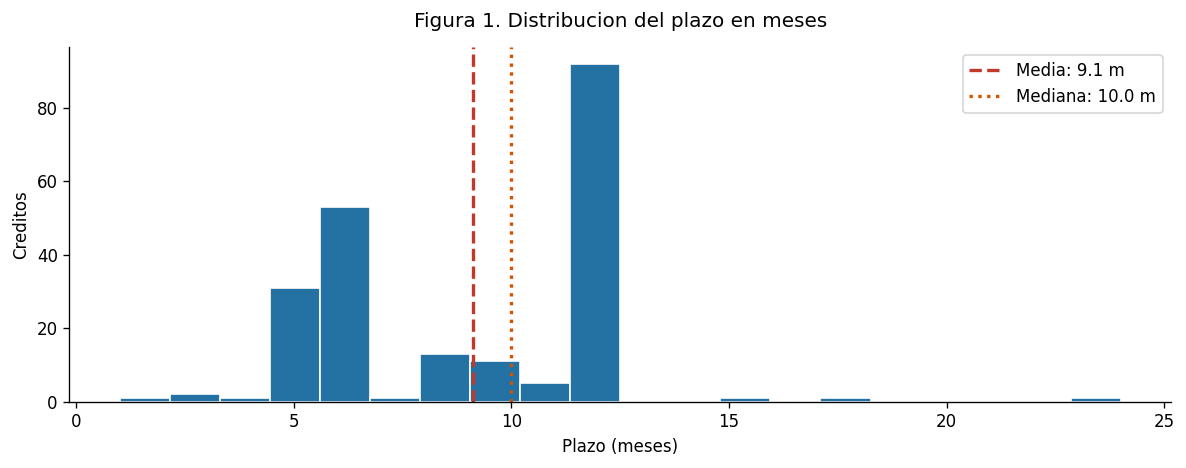

In [9]:
fig, ax = plt.subplots(figsize=(10,4))
ax.hist(df['plazo_meses'], bins=20, color=AZUL, edgecolor='white', lw=0.8)
ax.axvline(df['plazo_meses'].mean(),   color=ROJO,    lw=2, ls='--',
           label=f'Media: {df["plazo_meses"].mean():.1f} m')
ax.axvline(df['plazo_meses'].median(), color=NARANJA, lw=2, ls=':',
           label=f'Mediana: {df["plazo_meses"].median():.1f} m')
ax.set_title('Figura 1. Distribucion del plazo en meses', pad=12)
ax.set_xlabel('Plazo (meses)'); ax.set_ylabel('Creditos'); ax.legend()
plt.tight_layout()
plt.savefig(str(ROOT/'outputs'/'fig_01_plazo.png'), bbox_inches='tight')
plt.show()

---
## 3. Panorama de la mora

Antes de analizar causas se dimensiona el problema.

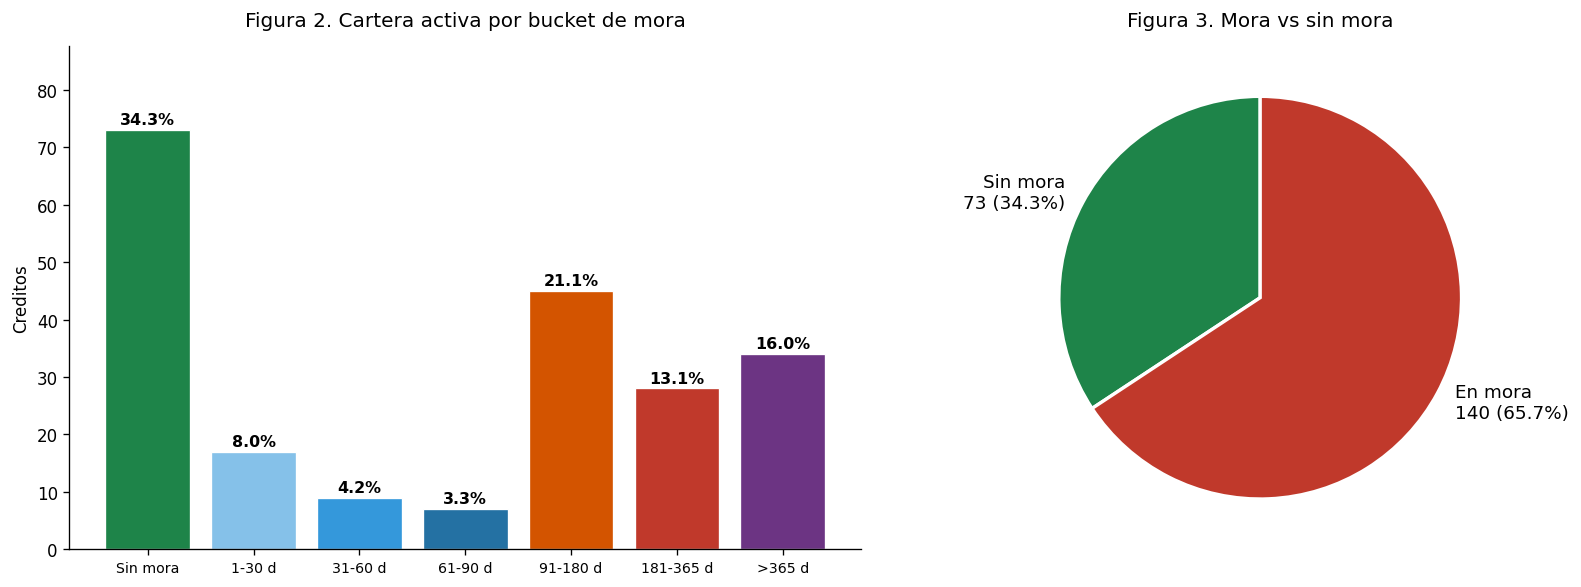

Mediana  : 91 dias
Promedio : 170 dias
Maximo   : 728 dias (2.0 anios)
Mora grave (>90d): 107 creditos (50.2%)


In [10]:
bins   = [-1,0,30,60,90,180,365,np.inf]
labels = ['Sin mora','1-30 d','31-60 d','61-90 d','91-180 d','181-365 d','>365 d']
df['bucket'] = pd.cut(df['dias_mora'], bins=bins, labels=labels)
conteo = df['bucket'].value_counts().reindex(labels)
pct    = (conteo/len(df)*100).round(1)
colores_b = [VERDE,'#85C1E9','#3498DB',AZUL,NARANJA,ROJO,'#6C3483']

fig, axes = plt.subplots(1,2,figsize=(14,5))
bars = axes[0].bar(labels, conteo.values, color=colores_b, edgecolor='white', lw=0.8)
for bar,p,c in zip(bars,pct.values,conteo.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{p:.1f}%', ha='center', va='bottom', fontsize=9.5, fontweight='bold')
axes[0].set_title('Figura 2. Cartera activa por bucket de mora', pad=12)
axes[0].set_ylabel('Creditos'); axes[0].set_ylim(0, conteo.max()*1.2)
axes[0].tick_params(axis='x', labelsize=8.5)

mora_si=df['en_mora'].sum(); mora_no=len(df)-mora_si
axes[1].pie(
    [mora_no, mora_si],
    labels=[f'Sin mora\n{mora_no} ({mora_no/len(df)*100:.1f}%)',
            f'En mora\n{mora_si} ({mora_si/len(df)*100:.1f}%)'],
    colors=[VERDE,ROJO], startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2}, textprops={'fontsize':11})
axes[1].set_title('Figura 3. Mora vs sin mora', pad=12)
plt.tight_layout()
plt.savefig(str(ROOT/'outputs'/'fig_02_panorama.png'), bbox_inches='tight')
plt.show()
print(f'Mediana  : {int(df["dias_mora"].median())} dias')
print(f'Promedio : {df["dias_mora"].mean():.0f} dias')
print(f'Maximo   : {df["dias_mora"].max()} dias ({df["dias_mora"].max()/365:.1f} anios)')
print(f'Mora grave (>90d): {df["dias_mora"].gt(90).sum()} creditos '
      f'({df["dias_mora"].gt(90).mean()*100:.1f}%)')

---
## 4. Monto vs Mora

Se usa **correlacion de Spearman** porque `dias_mora` es asimetrica (mediana=0, cola hasta 728 dias). Pearson requiere normalidad y es sensible a valores extremos; Spearman trabaja con rangos y es robusto.

In [11]:
from scipy.stats import spearmanr

df_m30 = df[df["monto"] <= 30000].copy()
en_m30 = df_m30[df_m30["en_mora"]==1]
no_m30 = df_m30[df_m30["en_mora"]==0]

r_m, p_m = spearmanr(df_m30["monto"], df_m30["dias_mora"])
df_m30["seg_monto"] = pd.qcut(df_m30["monto"], q=3,
                          labels=["Bajo (<P33)","Medio (P33-P66)","Alto (>P66)"])
medias_m   = df_m30.groupby("seg_monto", observed=True)["dias_mora"].mean().round(1)
pct_mora_m = df_m30.groupby("seg_monto", observed=True)["en_mora"].mean().mul(100).round(1)
cnt_m      = df_m30.groupby("seg_monto", observed=True)["dias_mora"].count()

fig, axes = plt.subplots(1,2,figsize=(13,5))
axes[0].scatter(no_m30["monto"], no_m30["dias_mora"], alpha=0.35, color=GRIS, s=28,
                label="Sin mora", edgecolors="none")
axes[0].scatter(en_m30["monto"], en_m30["dias_mora"], alpha=0.50, color=ROJO, s=28,
                label="En mora",  edgecolors="none")
z  = np.polyfit(df_m30["monto"], df_m30["dias_mora"], 1)
xr = np.linspace(df_m30["monto"].min(), df_m30["monto"].max(), 200)
axes[0].plot(xr, np.poly1d(z)(xr), color=AZUL, lw=2.5, label="Tendencia")
axes[0].set_title("Figura 4a. Monto vs Dias de mora (hasta $30K)", pad=10)
axes[0].set_xlabel("Monto prestado (MXN)"); axes[0].set_ylabel("Dias de mora")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x/1000:.0f}K"))
axes[0].legend(fontsize=9)
stxt = "(*)" if p_m<0.05 else "(n.s.)"
axes[0].text(0.05,0.92, f"r = {r_m:+.2f}  p={p_m:.3f} {stxt}",
             transform=axes[0].transAxes, fontsize=10,
             bbox=dict(boxstyle="round,pad=0.3",facecolor="#EBF5FB",edgecolor=AZUL))
df_m30.boxplot(column="dias_mora", by="seg_monto", ax=axes[1], patch_artist=True,
           boxprops=dict(facecolor=AZUL+"33",color=AZUL),
           medianprops=dict(color=ROJO,lw=2.5),
           whiskerprops=dict(color=AZUL), capprops=dict(color=AZUL),
           flierprops=dict(marker="o",color=AZUL,alpha=0.3,markersize=3))
for i,(seg,val) in enumerate(medias_m.items()):
    axes[1].text(i+1, val+8, f"media={val:.0f}d" + "
" + f"n={cnt_m[seg]}",
                 ha="center", fontsize=9, color=AZUL, fontweight="bold")
axes[1].set_title("Figura 4b. Dias de mora por tercil de monto ($0-$30K)", pad=10)
axes[1].set_xlabel("Segmento"); axes[1].set_ylabel("Dias de mora")
plt.suptitle("")
plt.tight_layout()
plt.show()
print(f"n = {len(df_m30)} creditos (monto <= $30K, excluidos {len(df)-len(df_m30)} outliers)")
print(f"r Spearman = {r_m:+.4f}  p = {p_m:.4f}  {stxt}")
for seg in medias_m.index:
    print(f"  {str(seg):22s}: media={medias_m[seg]:.1f}d  {pct_mora_m[seg]:.1f}% en mora")

**Conclusion — Monto:** Relacion debil pero estadisticamente significativa (r = +0.15, p = 0.028). Los creditos de monto alto tienden a mas dias de mora, pero la relacion es demasiado debil para usarse como predictor individual.

---
## 5. Plazo vs Mora

Se analiza si los creditos a mayor plazo acumulan mas dias de mora.

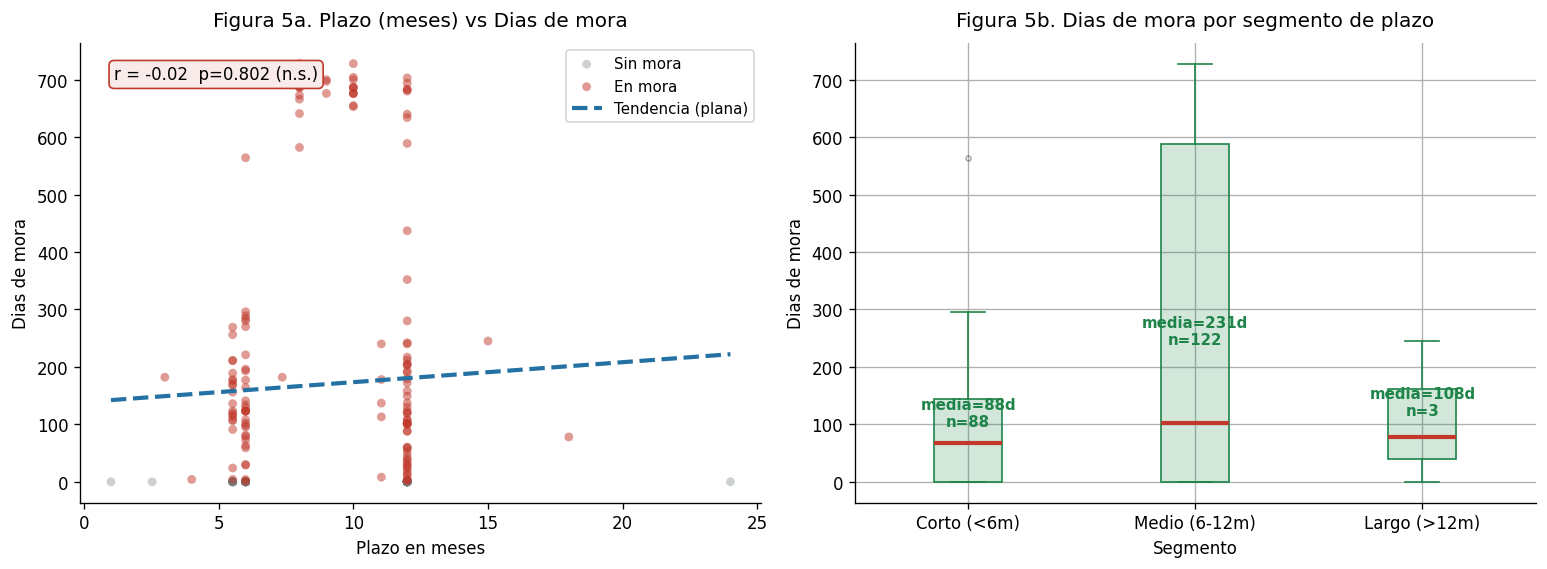

r Spearman = -0.0173  p = 0.8015  NO significativa
  Corto (<6m)           : media=88.2d  60.2% en mora  n=88
  Medio (6-12m)         : media=231.1d  69.7% en mora  n=122
  Largo (>12m)          : media=107.7d  66.7% en mora  n=3


In [12]:
r_p, p_p = spearmanr(df['plazo_meses'], df['dias_mora'])
df['seg_plazo'] = pd.cut(df['plazo_meses'], bins=[0,6,12,np.inf],
                         labels=['Corto (<6m)','Medio (6-12m)','Largo (>12m)'])
medias_p   = df.groupby('seg_plazo', observed=True)['dias_mora'].mean().round(1)
pct_mora_p = df.groupby('seg_plazo', observed=True)['en_mora'].mean().mul(100).round(1)
cnt_p      = df.groupby('seg_plazo', observed=True)['dias_mora'].count()

fig, axes = plt.subplots(1,2,figsize=(13,5))
axes[0].scatter(no['plazo_meses'], no['dias_mora'], alpha=0.35, color=GRIS, s=28,
                label='Sin mora', edgecolors='none')
axes[0].scatter(en['plazo_meses'], en['dias_mora'], alpha=0.50, color=ROJO, s=28,
                label='En mora',  edgecolors='none')
z2  = np.polyfit(df['plazo_meses'], df['dias_mora'], 1)
xr2 = np.linspace(df['plazo_meses'].min(), df['plazo_meses'].max(), 200)
axes[0].plot(xr2, np.poly1d(z2)(xr2), color=AZUL, lw=2.5, ls='--',
             label='Tendencia (plana)')
axes[0].set_title('Figura 5a. Plazo (meses) vs Dias de mora', pad=10)
axes[0].set_xlabel('Plazo en meses'); axes[0].set_ylabel('Dias de mora')
axes[0].legend(fontsize=9)
axes[0].text(0.05,0.92, f'r = {r_p:+.2f}  p={p_p:.3f} (n.s.)',
             transform=axes[0].transAxes, fontsize=10,
             bbox=dict(boxstyle='round,pad=0.3',facecolor='#F9EBEA',edgecolor=ROJO))
df.boxplot(column='dias_mora', by='seg_plazo', ax=axes[1], patch_artist=True,
           boxprops=dict(facecolor=VERDE+'33',color=VERDE),
           medianprops=dict(color=ROJO,lw=2.5),
           whiskerprops=dict(color=VERDE), capprops=dict(color=VERDE),
           flierprops=dict(marker='o',color=VERDE,alpha=0.3,markersize=3))
for i,(seg,val) in enumerate(medias_p.items()):
    axes[1].text(i+1, val+8, f'media={val:.0f}d\nn={cnt_p[seg]}',
                 ha='center', fontsize=9, color=VERDE, fontweight='bold')
axes[1].set_title('Figura 5b. Dias de mora por segmento de plazo', pad=10)
axes[1].set_xlabel('Segmento'); axes[1].set_ylabel('Dias de mora')
plt.suptitle('')
plt.tight_layout()
plt.savefig(str(ROOT/'outputs'/'fig_04_plazo.png'), bbox_inches='tight')
plt.show()
print(f'r Spearman = {r_p:+.4f}  p = {p_p:.4f}  NO significativa')
for seg in medias_p.index:
    print(f'  {str(seg):22s}: media={medias_p[seg]:.1f}d  {pct_mora_p[seg]:.1f}% en mora  n={cnt_p[seg]}')

**Conclusion — Plazo:** Sin relacion estadistica (r = -0.02, p = 0.80). Creditos a 3 meses y a 24 meses tienen mora equivalente. Hipotesis: el plazo se calibra segun capacidad de pago, lo que equilibra el riesgo entre segmentos y neutraliza su efecto.

---
## 6. Tasa de Interés vs Mora

La tasa proviene de un archivo complementario (`CapturadeAcreditados`). **2 créditos sin match** (IDs 1167 y 1272) se excluyen solo de este análisis; el resto del notebook los conserva. Quedan **211 registros** para este análisis.

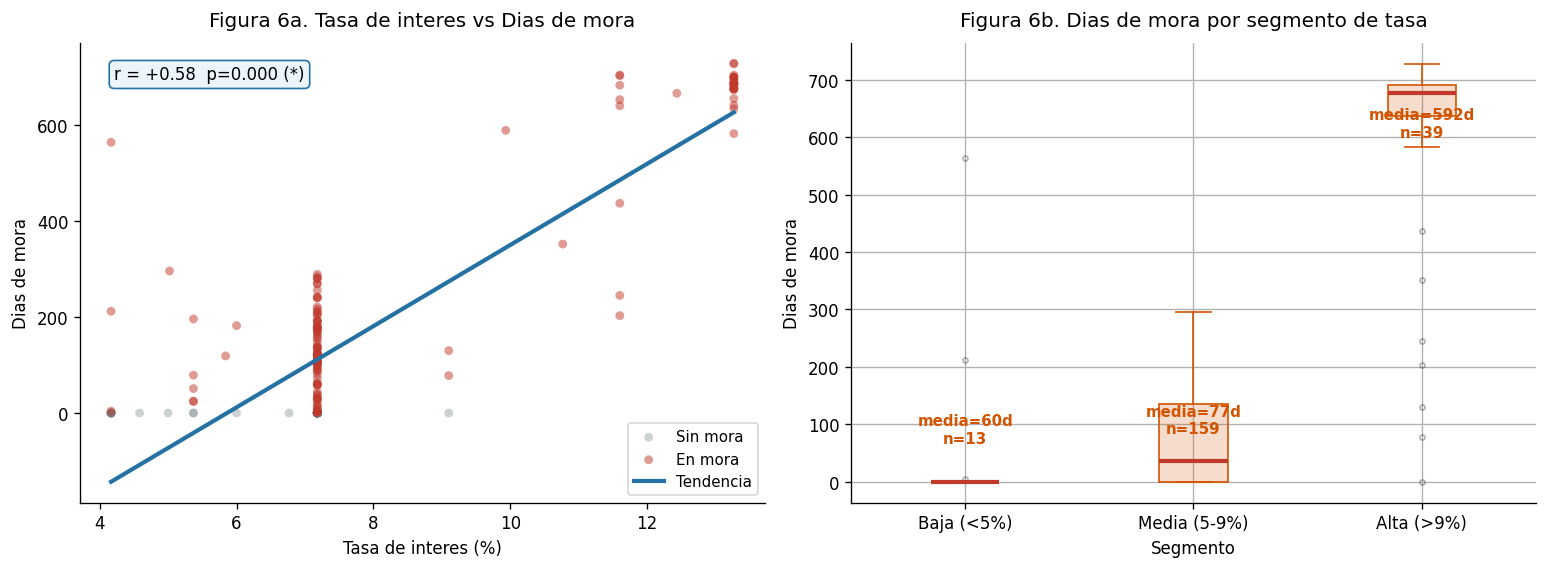

r Spearman = +0.5752  p = 0.0000  (*)
  Baja (<5%)        : media=60.0d  23.1% en mora  n=13
  Media (5-9%)      : media=76.7d  61.0% en mora  n=159
  Alta (>9%)        : media=592.5d  97.4% en mora  n=39


In [13]:
df_t = df.dropna(subset=['tasa_interes']).copy()
en_t = df_t[df_t['en_mora']==1]; no_t = df_t[df_t['en_mora']==0]

r_t, p_t = spearmanr(df_t['tasa_interes'], df_t['dias_mora'])
stxt_t = '(*)' if p_t < 0.05 else '(n.s.)'

# Segmentos de tasa
df_t['seg_tasa'] = pd.cut(df_t['tasa_interes'],
                          bins=[0, 5, 9, np.inf],
                          labels=['Baja (<5%)','Media (5-9%)','Alta (>9%)'])
medias_t   = df_t.groupby('seg_tasa', observed=True)['dias_mora'].mean().round(1)
pct_mora_t = df_t.groupby('seg_tasa', observed=True)['en_mora'].mean().mul(100).round(1)
cnt_t      = df_t.groupby('seg_tasa', observed=True)['dias_mora'].count()

fig, axes = plt.subplots(1,2,figsize=(13,5))
axes[0].scatter(no_t['tasa_interes'], no_t['dias_mora'], alpha=0.35, color=GRIS, s=28,
                label='Sin mora', edgecolors='none')
axes[0].scatter(en_t['tasa_interes'], en_t['dias_mora'], alpha=0.50, color=ROJO, s=28,
                label='En mora', edgecolors='none')
z3  = np.polyfit(df_t['tasa_interes'], df_t['dias_mora'], 1)
xr3 = np.linspace(df_t['tasa_interes'].min(), df_t['tasa_interes'].max(), 200)
axes[0].plot(xr3, np.poly1d(z3)(xr3), color=AZUL, lw=2.5, label='Tendencia')
axes[0].set_title('Figura 6a. Tasa de interes vs Dias de mora', pad=10)
axes[0].set_xlabel('Tasa de interes (%)'); axes[0].set_ylabel('Dias de mora')
axes[0].legend(fontsize=9)
axes[0].text(0.05, 0.92, f'r = {r_t:+.2f}  p={p_t:.3f} {stxt_t}',
             transform=axes[0].transAxes, fontsize=10,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#EBF5FB', edgecolor=AZUL))

df_t.boxplot(column='dias_mora', by='seg_tasa', ax=axes[1], patch_artist=True,
             boxprops=dict(facecolor=NARANJA+'33', color=NARANJA),
             medianprops=dict(color=ROJO, lw=2.5),
             whiskerprops=dict(color=NARANJA), capprops=dict(color=NARANJA),
             flierprops=dict(marker='o', color=NARANJA, alpha=0.3, markersize=3))
for i,(seg,val) in enumerate(medias_t.items()):
    axes[1].text(i+1, val+8, f'media={val:.0f}d\nn={cnt_t[seg]}',
                 ha='center', fontsize=9, color=NARANJA, fontweight='bold')
axes[1].set_title('Figura 6b. Dias de mora por segmento de tasa', pad=10)
axes[1].set_xlabel('Segmento'); axes[1].set_ylabel('Dias de mora')
plt.suptitle('')
plt.tight_layout()
plt.savefig(str(ROOT/'outputs'/'fig_05_tasa.png'), bbox_inches='tight')
plt.show()
print(f'r Spearman = {r_t:+.4f}  p = {p_t:.4f}  {stxt_t}')
for seg in medias_t.index:
    print(f'  {str(seg):18s}: media={medias_t[seg]:.1f}d  {pct_mora_t[seg]:.1f}% en mora  n={cnt_t[seg]}')

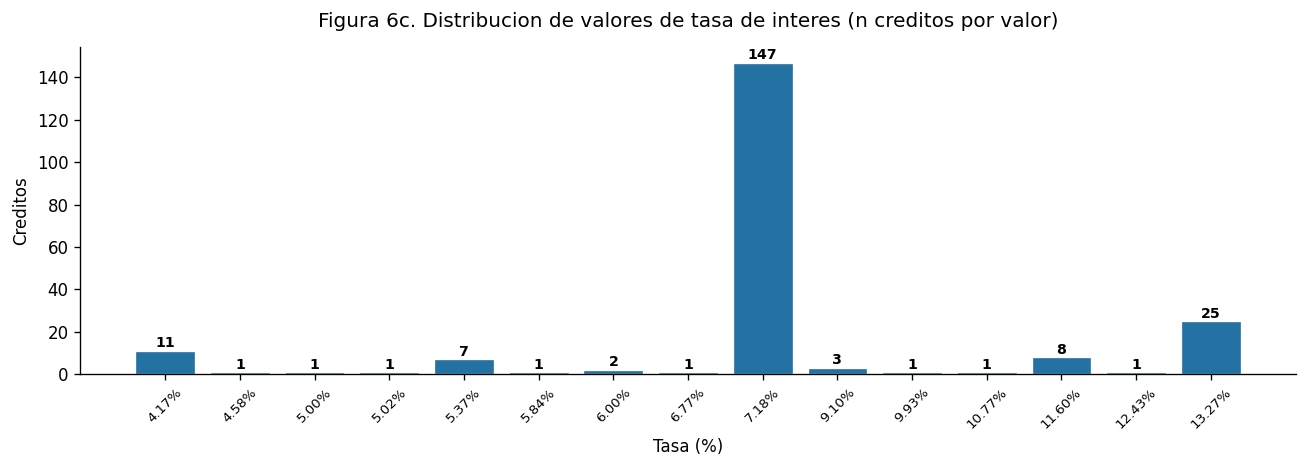

Valor mas frecuente: 7.1800%  (147 creditos = 69.7%)
Si un valor concentra >60% de los creditos, la tasa es parametro de producto, no de riesgo.


In [14]:
# Distribucion de la tasa — ver si es parametro de producto o de riesgo
tasa_vals = df_t['tasa_interes'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(11,4))
bars = ax.bar([f'{v:.2f}%' for v in tasa_vals.index], tasa_vals.values,
              color=AZUL, edgecolor='white', lw=0.8)
for bar,val in zip(bars, tasa_vals.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            str(val), ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax.set_title('Figura 6c. Distribucion de valores de tasa de interes (n creditos por valor)', pad=12)
ax.set_xlabel('Tasa (%)'); ax.set_ylabel('Creditos')
ax.tick_params(axis='x', labelrotation=45, labelsize=8)
plt.tight_layout()
plt.savefig(str(ROOT/'outputs'/'fig_05b_tasa_dist.png'), bbox_inches='tight')
plt.show()
print(f'Valor mas frecuente: {tasa_vals.idxmax():.4f}%  ({tasa_vals.max()} creditos = {tasa_vals.max()/len(df_t)*100:.1f}%)')
print('Si un valor concentra >60% de los creditos, la tasa es parametro de producto, no de riesgo.')

**Conclusión — Tasa de Interés:** Relación positiva fuerte (r = +0.58, p < 0.001). Es la variable con mayor poder predictivo del análisis.

| Segmento | % en mora | Media días mora | n |
|---|---|---|---|
| Tasa baja (<5%) | 23.1% | 60 días | 13 |
| Tasa media (5–9%) | 61.0% | 77 días | 159 |
| **Tasa alta (>9%)** | **97.4%** | **593 días** | **39** |

Los créditos con tasa alta tienen mora casi universal (97%) y en promedio casi 2 años de atraso. La tasa refleja el segmento o nivel de riesgo del producto — no es una tasa de castigo posterior, sino que los productos de mayor tasa se colocaron en perfiles de mayor riesgo.

---
## 7. Modelo combinado: monto, plazo y tasa juntos

**Regresion logistica** para estimar la probabilidad de entrar en mora. Se usan los 211 registros con tasa disponible. Resultados en **Odds Ratios**: OR < 1 reduce la probabilidad; OR > 1 la aumenta.

In [15]:
vars_modelo = ['monto','plazo_meses','tasa_interes']
df_m  = df.dropna(subset=['tasa_interes']).copy()
X_log = sm.add_constant(df_m[vars_modelo])
logit = sm.Logit(df_m['en_mora'], X_log).fit(disp=False)
ci = logit.conf_int(); pv = logit.pvalues
def sig(p): return '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'

or_df = pd.DataFrame({
    'Variable':        ['Monto','Plazo (meses)','Tasa de interes'],
    'Odds Ratio':      np.exp(logit.params[vars_modelo]).round(4).values,
    'IC 95% inferior': np.exp(ci.loc[vars_modelo, 0]).round(4).values,
    'IC 95% superior': np.exp(ci.loc[vars_modelo, 1]).round(4).values,
    'p-value':         pv[vars_modelo].round(4).values,
    'Sig.': [sig(pv[v]) for v in vars_modelo]
})
display(
    or_df.set_index('Variable').style
    .set_caption('Tabla 5. Regresion logistica — Odds Ratios (n=211)')
    .set_table_styles([{'selector':'caption','props':[('font-size','13px'),('font-weight','bold'),('caption-side','top')]}])
    .format({'Odds Ratio':'{:.4f}','IC 95% inferior':'{:.4f}',
             'IC 95% superior':'{:.4f}','p-value':'{:.4f}'})
    .apply(lambda x: ['background-color:#D5F5E3' if '***' in str(v) or '**' in str(v)
                      else 'background-color:#FADBD8' if 'n.s.' in str(v)
                      else '' for v in x], axis=1)
)

,Odds Ratio,IC 95% inferior,IC 95% superior,p-value,Sig.
Variable,,,,,
Monto,1.0000,1.0000,1.0000,0.5649,n.s.
Plazo (meses),0.9438,0.8579,1.0382,0.2343,n.s.
Tasa de interes,1.7433,1.3402,2.2677,0.0000,***


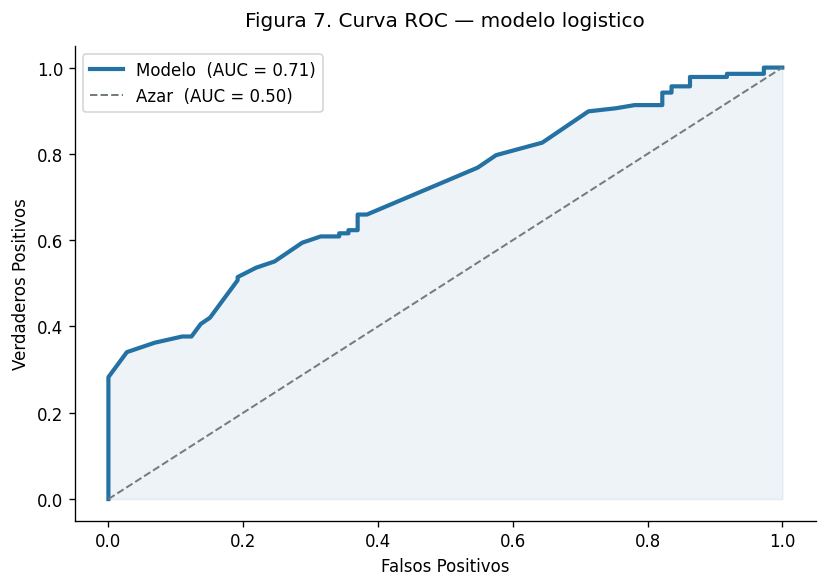

AUC = 0.7124  (0.50=azar | 0.71=este modelo | 1.00=perfecto)


In [16]:
y_proba   = logit.predict(X_log)
auc       = roc_auc_score(df_m['en_mora'], y_proba)
fpr,tpr,_ = roc_curve(df_m['en_mora'], y_proba)

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(fpr, tpr, color=AZUL, lw=2.5, label=f'Modelo  (AUC = {auc:.2f})')
ax.plot([0,1],[0,1], color=GRIS, ls='--', lw=1.2, label='Azar  (AUC = 0.50)')
ax.fill_between(fpr, tpr, alpha=0.08, color=AZUL)
ax.set_xlabel('Falsos Positivos'); ax.set_ylabel('Verdaderos Positivos')
ax.set_title('Figura 7. Curva ROC — modelo logistico', pad=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(str(ROOT/'outputs'/'fig_06_roc.png'), bbox_inches='tight')
plt.show()
print(f'AUC = {auc:.4f}  (0.50=azar | {auc:.2f}=este modelo | 1.00=perfecto)')

**Conclusión — Modelo combinado:** La tasa domina el modelo. AUC = 0.71 — discriminación moderada-buena, mejor que cualquier variable individual.

| Variable | Odds Ratio | p-value | Resultado |
|---|---|---|---|
| Monto | 1.00 | 0.565 | No significativo |
| Plazo (meses) | 0.94 | 0.234 | No significativo |
| **Tasa de interés** | **1.74** | **< 0.001** | **Único predictor significativo** |

OR tasa = 1.74: por cada punto porcentual adicional de tasa, la probabilidad de mora aumenta 74%. Monto y plazo pierden toda señal cuando se controla por tasa.

---
## 8. Conclusiones y recomendaciones

### ¿Qué explica la mora en esta cartera?

**La tasa de interés es el único predictor real.** Con r = +0.58 y OR = 1.74 (p < 0.001), separa claramente los grupos: tasa baja → 23% en mora; tasa alta → 97% en mora. Esto sugiere que la tasa refleja el segmento de riesgo del producto, no es un precio arbitrario.

**El monto y el plazo no explican la mora.** Ambos pierden significancia cuando se incluye la tasa en el modelo. El plazo está calibrado según capacidad de pago; el monto tiene señal débil solo cuando la tasa no está en el modelo.

**AUC = 0.71** con tres variables de producto. Hay margen de mejora incorporando variables del cliente y contexto operativo:

- **Coordinación / sucursal** — Valle de Bravo concentra el 63% del saldo vencido
- **Sector económico** — proxy de vulnerabilidad del negocio
- **Promotor** — la calidad de originación impacta la cartera

---

### Resumen de hallazgos

| Pregunta | Hallazgo | Evidencia |
|---|---|---|
| ¿Monto → mora? | Señal débil, desaparece al controlar por tasa | r = +0.15 (p = 0.028) |
| ¿Plazo → mora? | Sin relación | r = -0.02 (p = 0.80) |
| ¿Tasa → mora? | Relación fuerte, principal predictor | r = +0.58 (p < 0.001), OR = 1.74 |
| ¿Las 3 juntas? | Poder moderado-bueno, dominado por tasa | AUC = 0.71 |

**Recomendación 1:** Los productos de tasa alta (>9%) concentran el riesgo crítico. Enfocar gestión preventiva en esa cartera.

**Recomendación 2:** El siguiente análisis debe incorporar coordinación, sector económico y promotor para superar AUC = 0.80.